<a href="https://colab.research.google.com/github/Nahom32/Resonance-Experiments/blob/main/Agricultural_Indice_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install rasterio

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import os
root_dir = '/content/drive/My Drive/hyperspectral_analysis/'
results = os.walk(root_dir)
tif_files = []
txt_files =[]
for root, dirs, files in results:
  for file in files:
    _, extension = os.path.splitext(file)
    if extension == '.tif':
      tif_files.append(file)
    elif extension == '.txt':
      txt_files.append(file)
  print(tif_files)
  print(txt_files)

['AVHRR-Land_v004_AVH13C1_NOAA-18_20131231_c20140415040725_ndvi.tif', 'AVHRR-Land_v004_AVH13C1_NOAA-18_20131231_c20140415040725_tod.tif', 'AVHRR-Land_v004_AVH13C1_NOAA-18_20131231_c20140415040725_qa.tif']
['AVHRR-Land_v004_AVH13C1_NOAA-18_20131231_c20140415040725.txt']


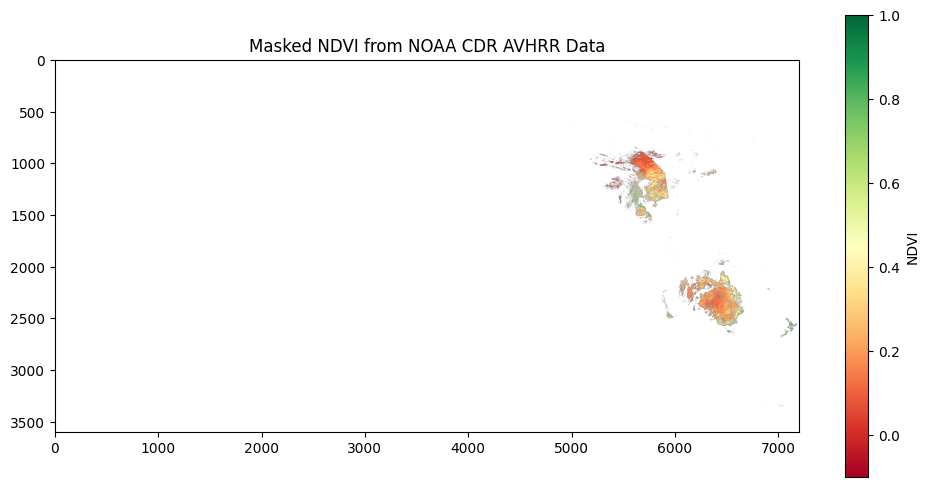

Masked NDVI saved to /content/drive/MyDrive/hyperspectral_analysis/masked_ndvi.tif


In [19]:
# Step 1: Define file paths (replace 'your_directory' with your actual folder name)
import rasterio
import numpy as np
import matplotlib.pyplot as plt
base_path = '/content/drive/MyDrive/hyperspectral_analysis/'
ndvi_file = base_path +'AVHRR-Land_v004_AVH13C1_NOAA-18_20131231_c20140415040725_ndvi.tif'  # Assuming exported from subdataset
qa_file = base_path + 'AVHRR-Land_v004_AVH13C1_NOAA-18_20131231_c20140415040725_qa.tif'
timeofday_file = base_path + 'AVHRR-Land_v004_AVH13C1_NOAA-18_20131231_c20140415040725_tod.tif'

# Step 2: Load the TIFF files
with rasterio.open(ndvi_file) as ndvi_src:
    ndvi_raw = ndvi_src.read(1)  # Assume single band
    meta = ndvi_src.meta.copy()

with rasterio.open(qa_file) as qa_src:
    qa = qa_src.read(1)

with rasterio.open(timeofday_file) as tod_src:
    tod_raw = tod_src.read(1)

# Validate shapes match
if ndvi_raw.shape != qa.shape or ndvi_raw.shape != tod_raw.shape:
    raise ValueError("TIFF files must have the same dimensions")

# Step 3: Apply scaling factors from metadata
# NDVI: raw values * 0.0001, valid -0.1 to 1.0, fill -9999 -> NaN
ndvi = ndvi_raw.astype(np.float32) * 0.0001
ndvi[ndvi_raw == -9999] = np.nan

# TIMEOFDAY: raw * 0.01, units hours, valid 0-23.99, fill -9999 -> NaN
timeofday = tod_raw.astype(np.float32) * 0.01
timeofday[tod_raw == -9999] = np.nan

# Step 4: Decode and apply QA mask
# QA is 16-bit integer flags (bit 15 MSB to bit 0 LSB)
# Define bad conditions: cloudy (bit1), cloud_shadow (bit2), night (bit6), invalid channels (bits8-12), etc.
# For good data: channels 1-5 valid (bit7=1), not cloudy (bit1=0), not shadow (bit2=0), not night (bit6=0)
good_mask = (
    (qa & 0x0080) == 0x0080  # bit7=1: channels valid
) & (
    (qa & 0x0002) == 0       # bit1=0: not cloudy
) & (
    (qa & 0x0004) == 0       # bit2=0: not cloud shadow
) & (
    (qa & 0x0040) == 0       # bit6=0: not night
) & (
    (qa & 0x0100) == 0       # bit8=0: ch1 valid (not invalid)
) & (
    (qa & 0x0200) == 0       # bit9=0: ch2 valid
)  # Add more as needed, e.g., & ((qa & 0x0008) == 0) for not water

# Optionally, mask other issues: BRDF problem (bit14=0x4000), polar (bit15=0x8000), etc.
# good_mask &= ((qa & 0x4000) == 0)  # not BRDF issue

# Apply mask to NDVI (set bad to NaN)
masked_ndvi = np.where(good_mask, ndvi, np.nan)

# Step 5: Plot masked NDVI (global view, may need subsampling for large grids)
plt.figure(figsize=(12, 6))
plt.imshow(masked_ndvi, cmap='RdYlGn', vmin=-0.1, vmax=1.0)
plt.colorbar(label='NDVI')
plt.title('Masked NDVI from NOAA CDR AVHRR Data')
plt.show()

# Step 6: Save masked NDVI as new TIFF
output_path = base_path + 'masked_ndvi.tif'
meta.update(dtype='float32')
with rasterio.open(output_path, 'w', **meta) as dst:
    dst.write(masked_ndvi, 1)
    print(f"Masked NDVI saved to {output_path}")